In [83]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score
df = pd.read_csv('data.csv')
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


In [84]:
df.isna().sum()#проверка наличия NaN

Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

In [85]:
df['Fuel_Type'].unique()#с этой строчки идёт замена строковых значений на int

<ArrowStringArray>
['Diesel', 'Petrol', 'CNG']
Length: 3, dtype: str

In [86]:
size_map = {'Diesel' : 1, 'Petrol' : 2, 'CNG' : 3}
df['nFuel_Type'] = df['Fuel_Type'].map(size_map)
df = df.drop(columns=['Fuel_Type'])

In [87]:
print(df['Color'].unique())
size_map = {'Blue' : 1, 'Silver' : 2, 'Black' : 3, 'White' : 4, 'Grey' : 5, 'Red' : 6, 'Green' : 7, 'Yellow' : 8, 'Violet' : 9, 'Beige' : 10}
df['nColor'] = df['Color'].map(size_map)
df = df.drop(columns=['Color'])

<ArrowStringArray>
[  'Blue', 'Silver',  'Black',  'White',   'Grey',    'Red',  'Green',
 'Yellow', 'Violet',  'Beige']
Length: 10, dtype: str


Столбцы формата str заменены на int, чтобы модель работала с одинаковым форматом данных и для удобства визуализации

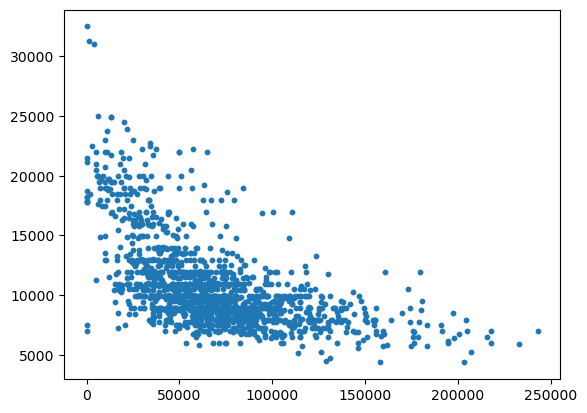

In [88]:
x = df['KM']
y = df['Price']
plt.scatter(x,y, s = 10)
plt.show()

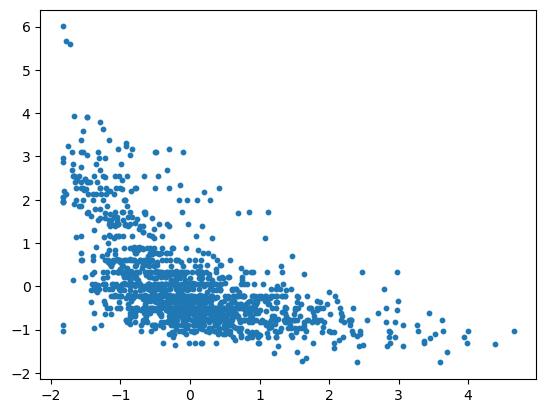

In [89]:
x = StandardScaler().fit_transform(df.loc[:,'KM'].to_frame())
y = StandardScaler().fit_transform(df.loc[:,'Price'].to_frame())
plt.scatter(x,y, s = 10)
plt.show()

In [90]:
df['KM'].describe()

count      1436.000000
mean      68533.259749
std       37506.448872
min           1.000000
25%       43000.000000
50%       63389.500000
75%       87020.750000
max      243000.000000
Name: KM, dtype: float64

In [91]:
df['Price'].describe()

count     1436.000000
mean     10730.824513
std       3626.964585
min       4350.000000
25%       8450.000000
50%       9900.000000
75%      11950.000000
max      32500.000000
Name: Price, dtype: float64

In [92]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=32)
#X_train, X_validative, y_train, y_validative = train_test_split(X_train, y_train, test_size=0.1, random_state=42)#кросс-валидация


In [93]:
df = df.drop(columns=['Id','Model'])
df.head()

,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,...,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar,nFuel_Type,nColor
0,13500,23,10,2002,46986,90,1,0,2000,3,...,0,0,0,1,0,0,0,0,1,1
1,13750,23,10,2002,72937,90,1,0,2000,3,...,0,0,0,1,0,0,0,0,1,2
2,13950,24,9,2002,41711,90,1,0,2000,3,...,0,0,0,1,0,0,0,0,1,1
3,14950,26,7,2002,48000,90,0,0,2000,3,...,0,0,0,1,0,0,0,0,1,3
4,13750,30,3,2002,38500,90,0,0,2000,3,...,0,1,0,1,0,0,0,0,1,3


0.6109357240396981
0.7339744471680955
0.6149363031829869
0.735796771753924
0.6149363043541972
0.7357967723410057


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


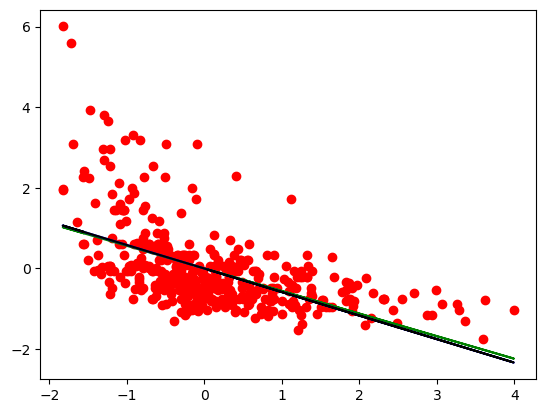

In [123]:
lin_reg = SGDRegressor(tol=.0001, eta0=.001)
lin_reg.fit(X_train, y_train)
predicted_reg = lin_reg.predict(X_test)
mae = mean_absolute_error(y_test, predicted_reg)#абсолютная
mse = mean_squared_error(y_test, predicted_reg)#квадратичная
plt.plot(X_test, predicted_reg, c = "green")
print(mae)#меньше, чем mse из-за меньшей чувствительности к выбросам
print(mse)

ridge = Ridge(alpha = 0.00001)
ridge.fit(X_train, y_train)
predicted_ridge = ridge.predict(X_test)
mae = mean_absolute_error(y_test, predicted_ridge)
mse = mean_squared_error(y_test, predicted_ridge)
plt.plot(X_test, predicted_ridge, c = "blue")
print(mae)
print(mse)

lasso = Lasso(alpha = 0.00000000000001)
lasso.fit(X_train, y_train)
predicted_lasso = lasso.predict(X_test)
mae = mean_absolute_error(y_test, predicted_lasso)
mse = mean_squared_error(y_test, predicted_lasso)
plt.plot(X_test, predicted_lasso, c = "black")
print(mae)
print(mse)

plt.scatter(X_test, y_test, c = "red")
plt.show()